<a href="https://colab.research.google.com/github/RajKumar0710/google-play-store-data-eda/blob/main/Capstone_EDA_Module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Play Store Apps Data Analysis







##### **Project Type**    - Exploratory Data Analysis
##### **Contribution**    - Individual
##### **Contributor** - Kottidi Raj Kumar


# **Project Summary -**

In this project we conducted Eploratory Data Analysis (EDA) on the two datasets provided, play_store_df and user_reviews_df. Our primary objective was to understand the quantitative and qualitative metrics provided along the datasets, clean, wrangle, merge, and visualize the data for conducting analysis and observing insights related to user behaviour, market trends, and product enhancement strategies.

Through various data visualisations charts we captured how user opinions varied with respect to various parameters, whether there is a difference in opinion among the users like ratings, installs etc. between paid and free apps vailable on the store, whether number of installs overall impacted the the sentiment polarity and sentiment subjectivity

Our findings reveal few important takeaways: overall review numbers scales with installs (0.63 correlation), app size and pricing have minimal negative correlation with user sentiment, and user ratings/sentiment remain stable even as applications reach massive global scale ($10^8+$ downloads). These insights empower app makers to optimize pricing structures, and improve user retention without compromising overall satisfaction.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


The goal is to analyse the Google Play Store envireonment by addressing key business parameters like
1. what features have the strongest impact on app popularity and user ratings?
2. How does user sentiment vary between Free and Paid apps across different target demographics?
3. What relationships exist among metrics and how can app makers use them to build better apps that can appeal user segment

#### **Define Your Business Objective?**

1. Identify how different metrics like size, category, price etc. impact user ratings and reviews
2. Analyse user sentiment to understand user satisfaction

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Dataset Loading

In [2]:
# Load Dataset

from google.colab import drive # importing and mounting drive onto coalb notebook
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
play_store_df = pd.read_csv('/content/drive/MyDrive/Almabetter_data/Play Store Data.csv') # loading play store data into the notebook

In [4]:
user_reviews_df = pd.read_csv('/content/drive/MyDrive/Almabetter_data/User Reviews.csv') # loading user reviews data into the notebook

# Making Copies of the dataframes

we are making a copy of each dataframe and will conduct our analysis on them so as that in case we accidently perform some irreversible damage to the copy we dont have to start from the beginning, we will have the original raw data available within the colab

In [5]:
play_store_df1 = play_store_df.copy() # copy of original play store dataframe

user_reviews_df1 = user_reviews_df.copy() # copy of riginal user reviews dataframe

### Dataset First View

In [6]:
# Dataset First Look
play_store_df1.head() # head of the play store dataframe


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [7]:
user_reviews_df1.head() # head of the user review dataframe

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


### Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns count
play_store_df1.shape  # shape gives the rows and columns count of a dataset

(10841, 13)

In [9]:
user_reviews_df1.shape # shape gives the rows and columns count of a dataset

(64295, 5)

### Dataset Information

In [10]:
# Dataset Info

play_store_df1.info()  # .info() gives the information regarding the dataset like number of rows, number of columns, column names and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [11]:
user_reviews_df1.info() # .info() gives the information regarding the dataset like number of rows, number of columns, column names and their data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


#### Duplicate Values

In [12]:
# Dataset Duplicate Value Count

play_store_df1.duplicated().sum() # It says there are 483 duplicated columns in the play store dataset

np.int64(483)

In [13]:
user_reviews_df1.duplicated().sum() # It says there are 33616 duplicated columns in the user reviews dataset

np.int64(33616)

#### Missing Values/Null Values

In [14]:
# Missing Values/Null Values Count

play_store_df1.isnull().sum() # gives us the number of null values for each column present in the dataset

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [15]:
user_reviews_df1.isnull().sum() # gives us the number of null values for each column present in the dataset

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [16]:
# Visualizing the missing values
# we will first calculate the percentage of null values for each column against the total rows in the dataset and then visualise them using barplot


play_store_nulls = (play_store_df1.isnull().sum()/len(play_store_df1))*100

In [17]:
play_store_nulls

,0
App,0.000000
Category,0.000000
Rating,13.596532
Reviews,0.000000
Size,0.000000
Installs,0.000000
Type,0.009224
Price,0.000000
Content Rating,0.009224
Genres,0.000000


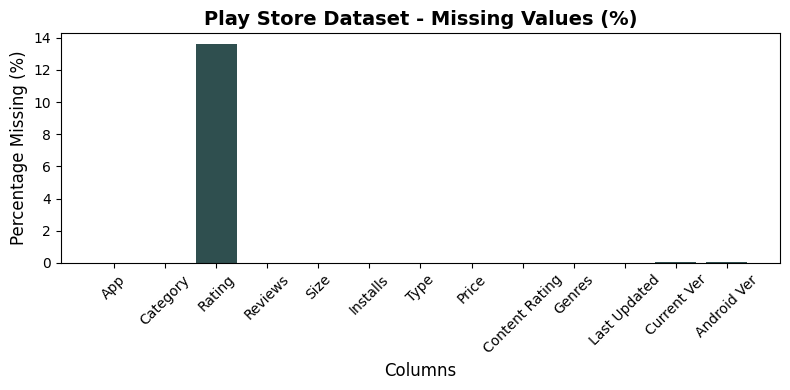

In [18]:
plt.figure(figsize=(8,4)) # setting the figure size

plt.bar(x = play_store_nulls.index, height=play_store_nulls.values, color = 'darkslategrey') # we plot bar chart for visualising the missing values in play store dataset
plt.title('Play Store Dataset - Missing Values (%)', fontsize = 14, fontweight ='bold') # title of the chart
plt.ylabel('Percentage Missing (%)', fontsize = 12) # y axis label name
plt.xlabel('Columns', fontsize = 12) # x axis label name

plt.xticks(rotation =45) # rotating the x axis ticks to 45 degrees so that they don't overlap on one another
plt.tight_layout()
plt.show()

In [19]:
user_reviews_nulls = (user_reviews_df1.isnull().sum()/len(user_reviews_df1))*100

In [20]:
user_reviews_nulls

,0
App,0.000000
Translated_Review,41.788631
Sentiment,41.780854
Sentiment_Polarity,41.780854
Sentiment_Subjectivity,41.780854


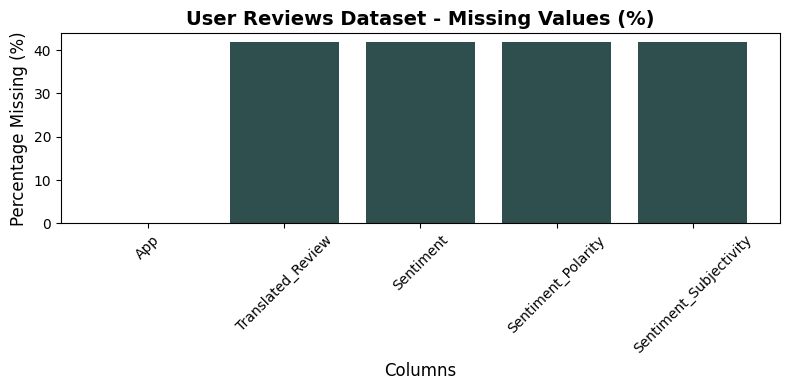

In [21]:
plt.figure(figsize=(8,4)) # setting the figure size

plt.bar(x = user_reviews_nulls.index, height=user_reviews_nulls.values, color = 'darkslategrey') # we plot bar chart for visualising the missing values in play store dataset
plt.title('User Reviews Dataset - Missing Values (%)', fontsize = 14, fontweight ='bold') # title of the chart
plt.ylabel('Percentage Missing (%)', fontsize = 12) # y axis label name
plt.xlabel('Columns', fontsize = 12) # x axis label name

plt.xticks(rotation =45) # rotating the x axis ticks to 45 degrees so that they don't overlap on one another
plt.tight_layout()
plt.show()

### What did you know about your dataset?

### Play Store Dataset

1. We observed that there are 10841 rows and 13 columns in it
2. There are 483 duplicates in the dataset which are to be removed
3. Datatype mismatch in few columns:
   i. reviews captured as object instead of int
   ii. price captured as object instead of float
   iii. size captured as object instead of int
   iv. Installs captured as object instead of int


### User Reviews Dataset

1. We observed that there are 64295 rows and 5 columns in it
2. There are 33616 duplicated rows in it implying huge chunk of redundant data
3. Unlike play Store Dataset there are no datatype mismatchs

## ***2. Understanding Your Variables***

In [22]:
# Dataset Columns of play store df
play_store_df1.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [23]:
# Dataset Columns of user reviews df
user_reviews_df1.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

In [24]:
# Dataset Describe
play_store_df1.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [25]:
# Dataset Describe
user_reviews_df1.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


### Variables Description

## Play Store Dataset Variables:


*   App: Name of the application.
*   Category: Category the app belongs to (e.g., GAME, FINANCE, FAMILY).
*   Rating: Average overall user rating of the app (ranging from 1.0 to 5.0).
*   Reviews: Total count of user reviews received by the app.
*   Size: The storage size of the app ( in MB/kb)
*   Installs: Total number of user installations.
*   Type: Monetization type indicating whether the app is Free or Paid.
*   Price: Cost of purchasing the app in USD (0 for free apps).
*   Content Rating: Target age group classification for the app (e.g.,   Everyone, Teen, Everyone 10+).
*   Genres: secondary sub-categories defining where the app belongs.
*   Last Updated: Date when the application was last updated on the Play Store.
*   Current Ver: Currently active version build of the app.
*   Android Ver: Minimum required Android operating system version to run the app.


## User Reviews Dataset Variables:


*   App: Name of the application.
*   Translated_Review: Text content of the user review (translated into English where applicable).
*   Sentiment: Categorical classification of the review sentiment (Positive, Negative, or Neutral).
*   Sentiment_Polarity: Numerical metric of measuring the positivity or negativity of the review (ranging from -1.0 for extreme negative to +1.0 for extreme positive)
*  Sentiment_Subjectivity: Numeric metric on how objective or subjective the review is



























### Check Unique Values for each variable.

In [26]:
# Check Unique Values for each variable.
for col in play_store_df1.columns:
    print(f"Column: {col}")
    print(f"Unique values: {play_store_df1[col].nunique()}")

Column: App
Unique values: 9660
Column: Category
Unique values: 34
Column: Rating
Unique values: 40
Column: Reviews
Unique values: 6002
Column: Size
Unique values: 462
Column: Installs
Unique values: 22
Column: Type
Unique values: 3
Column: Price
Unique values: 93
Column: Content Rating
Unique values: 6
Column: Genres
Unique values: 120
Column: Last Updated
Unique values: 1378
Column: Current Ver
Unique values: 2832
Column: Android Ver
Unique values: 33


In [27]:
# Check Unique Values for each variable.
for col in user_reviews_df1.columns:
  print(f"Column: {col}")
  print(f"Unique Values : {user_reviews_df1[col].nunique()}")

Column: App
Unique Values : 1074
Column: Translated_Review
Unique Values : 27994
Column: Sentiment
Unique Values : 3
Column: Sentiment_Polarity
Unique Values : 5410
Column: Sentiment_Subjectivity
Unique Values : 4474


## 3. ***Data Wrangling***

### Data Wrangling Code

### We are first cleaning the play_store_df1 dataframe

In [28]:
# Write your code to make your dataset analysis ready.

play_store_df1.drop(columns=['Android Ver', 'Current Ver', 'Last Updated'], axis =1, inplace = True) # we are dropping the last three columns in the play_store_df1 dataset which are more used for logging purposes by app developers

In [29]:
play_store_df1.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity


In [30]:
play_store_df1.shape

(10841, 10)

#### Now we are removing the duplicates in the play_store_df1 dataframe, apart from thet I want to check how many columns together make up an unique row

In [31]:
play_store_df1.iloc[:, 0].duplicated().sum() # we are using iloc to find out the duplicates, first column has 1181 duplicates

np.int64(1181)

In [32]:
play_store_df1.iloc[:, 0:2].duplicated().sum() # first and second columns together have 1096 duplicates

np.int64(1096)

In [33]:
play_store_df1.iloc[:, 0:3].duplicated().sum() # first to third columns together have 1086 duplicates

np.int64(1086)

In [34]:
play_store_df1.iloc[:, 0:4].duplicated().sum() # first to fourth columns together have 485 duplicates

np.int64(485)

In [35]:
play_store_df1.iloc[:, 0:5].duplicated().sum()

np.int64(485)

In [36]:
play_store_df1.iloc[:, 0:6].duplicated().sum()

np.int64(485)

#### From this we observe that there are 485 duplicated rows from first 4 rows and it doesn't change after that, so if we revmove these duplicated rows from the first 4 columns all the duplicated rows will be taken care of and we will keep the first of the duplicates from them

In [37]:
play_store_df1 = play_store_df1.drop_duplicates(subset = ['App', 'Category', 'Rating', 'Reviews'], keep = 'first')

In [38]:
# now we check if there are any duplicates left in the dataframe

play_store_df1.duplicated().sum() # as observed all the duplicates have been taken care of in this dataframe

np.int64(0)

In [39]:
play_store_df1.shape

(10356, 10)

#### We observe that App is the common column among both the datasets so we noticed one thing, some Apps have been duplicated just by changing the reviews or we can say same app has been captured multiple times with different reviews, so we sort the data frame with reviews column then delete the duplicates in App column keeping the first one, with that we will have the latest resord of that app as reviews are sorted in descending order. We particularly focused on this column because of absense of unique id column that is common in both play store and user reviews datasets.

In [40]:
play_store_df1 = play_store_df1.sort_values('Reviews', ascending= False)

In [41]:
play_store_df1 = play_store_df1.drop_duplicates('App', keep = 'first')

In [42]:
# now that the values in App column are unique we can proceed further with the other columns
play_store_df1[['App', 'Reviews']].duplicated().sum()

np.int64(0)

#Now we check if there are any anamolies in individual columns and their datatypes

In [43]:
play_store_df1[play_store_df1['App'].str.isnumeric()] # We are checking if there are any numeric values in the App column as it's datatype is object

# as observed there are no numeric values in this column so we go to next column

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres


In [44]:
play_store_df1[play_store_df1['Category'].str.isnumeric()] # we did not find any numeric values in the Category column

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres


In [45]:
# for rating we were not able to check via above method so we used value_counts to check if there are any otheres vakues apart from numbers

play_store_df1['Rating'].value_counts().sort_values() # and we did not find any objects here but we found one anamoly that has to be removed

# as we can see below we have all the ratings counts from 1-5 but there is a 19.0 here with count 1. Since a rating for an App cannot be 19.0 we will filter out that row from the dataset

,count
Rating,
19.0,1
1.2,1
1.4,3
1.5,3
1.6,4
1.7,8
1.8,8
2.1,8
1.9,11


#### Filtering out the row where rating is 19.0 or in general greater than 5.0

In [46]:
play_store_df1 =play_store_df1[(play_store_df1['Rating'] <= 5.0) | (play_store_df1['Rating'].isna())] # this took care of the anomoly there but we make sure null
#values stay there as we will fill them by mean median or mode

In [47]:
play_store_df1.shape

(9659, 10)

In [48]:
pd.set_option('display.max_rows', None)

In [120]:
play_store_df1['Reviews'].value_counts().head()  #we check the same for reviews too, there were no strings or texts there in them, but reviews is injected as object here, which we convert to int type later

,count
Reviews,
0,593
1,272
2,213
3,170
4,137


In [50]:
pd.reset_option('display.max_rows')

In [51]:
play_store_df1[play_store_df1['Size'].str.isnumeric()] # There are no numeric values in the size column but we obsereved there are 'M' and 'k' attached to it.
# We will remove 'M' and 'k's here and convert it to float type dividing the k's with 1024 to convert everything to MB, we will address this once all columns are cleared of anomolies

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres


In [52]:
play_store_df1[play_store_df1['Installs'].str.isnumeric()] #There are no numeric values in the size column but we obsereved there are '+' and ', 's attached to it.
# We will remove them and convert it to int later. Here it says installs are 0 but that is a valid numeric there so we ignore that here

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres
9148,Command & Conquer: Rivals,FAMILY,NaN,0,Varies with device,0,NaN,0,Everyone 10+,Strategy


In [53]:
play_store_df1['Type'].value_counts() # there are no anomolies here too as this column is object and only two values free and paid there

,count
Type,
Free,8902
Paid,756


In [54]:
play_store_df1['Price'].unique() # as we can see we have to remove $ symbol from it and convert it to float type

array(['0', '$2.49', '$2.99', '$0.99', '$3.99', '$4.99', '$399.99',
       '$1.99', '$79.99', '$7.49', '$4.49', '$9.99', '$5.99', '$13.99',
       '$4.29', '$1.70', '$14.99', '$12.99', '$1.49', '$19.99', '$1.50',
       '$3.49', '$1.29', '$7.99', '$29.99', '$1.59', '$11.99', '$3.02',
       '$39.99', '$89.99', '$6.99', '$2.90', '$1.00', '$19.40', '$5.49',
       '$1.75', '$8.99', '$5.00', '$3.08', '$18.99', '$299.99', '$17.99',
       '$379.99', '$8.49', '$2.56', '$15.46', '$2.95', '$1.97', '$19.90',
       '$1.26', '$4.80', '$2.60', '$24.99', '$4.77', '$400.00', '$16.99',
       '$10.99', '$4.59', '$389.99', '$33.99', '$1.76', '$46.99', '$3.90',
       '$2.00', '$2.50', '$10.00', '$14.00', '$3.95', '$6.49', '$3.28',
       '$1.20', '$2.59', '$4.84', '$37.99', '$1.61', '$4.60', '$9.00',
       '$15.99', '$74.99', '$3.88', '$3.04', '$4.85', '$1.04', '$109.99',
       '$154.99', '$1.96', '$28.99', '$200.00', '$30.99', '$3.61',
       '$394.99', '$25.99'], dtype=object)

In [55]:
play_store_df1['Content Rating'].unique() # there is one value that we have to address here that is unrated and we will replace it with mode of the column later

array(['Everyone', 'Teen', 'Everyone 10+', 'Mature 17+',
       'Adults only 18+', 'Unrated'], dtype=object)

In [56]:
play_store_df1['Genres'].value_counts() # there are no anamolies or discrepancies in this column

,count
Genres,
Tools,827
Entertainment,561
Education,510
Business,420
Medical,395
...,...
Role Playing;Brain Games,1
Lifestyle;Pretend Play,1
Music & Audio;Music & Video,1


In [57]:
play_store_df1.shape

(9659, 10)

## Now we will clean each column as mentioned in the comments one by one and fill/handle null values in them using mean median mode

In [58]:
play_store_df1['Reviews'] = pd.to_numeric(play_store_df1['Reviews'], errors = 'coerce') # we converted the Reviews column to numeric and used errors = coerece sp as to retain the nulls or errors

In [59]:
def convert_size(val):    # we defined a function to clean out 'M' and 'k's from the size column and divided the cells containing k with 1024
# to covert it to MB and we converted the values to float type

  if 'M' in str(val):
    return float(val.replace('M', ''))

  elif 'k' in str(val):
    return float(val.replace('k', ''))/1024

  else:
    return None

In [60]:
play_store_df1['Size'] = play_store_df1['Size'].apply(convert_size) # used the apply function to size column using convert_size function we defined

In [61]:
play_store_df1['Size'] = round(play_store_df1['Size'], 2) # we rounded off the size to 2 digits

In [62]:
median_size = play_store_df1['Size'].median() # we find the median to fill Na values in the size column

In [63]:
play_store_df1['Size'] = play_store_df1['Size'].fillna(median_size) # we fill the na values with median

In [64]:
play_store_df1['Size'].isnull().sum() # as we can see there are no null values in the size column

np.int64(0)

In [65]:
median_rating = play_store_df1['Rating'].median() # we find the median for the Rating column and fill na values

In [66]:
play_store_df1['Rating'] = play_store_df1['Rating'].fillna(median_rating)

In [67]:
play_store_df1['Rating'].isnull().sum() # all the null values in rating column have been filled with median

np.int64(0)

In [68]:
type_mode = play_store_df1['Type'].mode()[0] # since type is a descriptive column we fill the na values with mode of that column

In [69]:
play_store_df1['Type'] = play_store_df1['Type'].fillna(type_mode) # filling na values with mode of the column

In [70]:
def remove_plus(val):  # we defined a function to remove '+'  and ',' symbols from the installs column

  if '+' in str(val):
    return int(val.replace('+', '').replace(',', '').strip())
  else:
    return int(str(val).replace(',', '').strip())

In [71]:
play_store_df1['Installs'] = play_store_df1['Installs'].apply(remove_plus) # we use apply function to remove the symbols

In [72]:
play_store_df1['Installs'].value_counts() # as observed all the symbols are removed and column converted to int type

,count
Installs,
1000000,1418
100000,1113
10000,1030
10000000,934
1000,888
100,710
5000000,608
500000,505
50000,469


In [73]:
def remove_dollar(val): # we defined function to replace dollar symbol with blank in the Price column
  return float(val.replace("$", '').strip())

In [74]:
play_store_df1['Price'] = play_store_df1['Price'].apply(remove_dollar) # we used apply function to remove dollar from the price column

In [75]:
play_store_df1['Price'].value_counts() # as observed dollar symbols are removed

,count
Price,
0.00,8903
0.99,145
2.99,124
1.99,73
4.99,70
...,...
200.00,1
30.99,1
3.61,1


In [76]:
play_store_df1['Content Rating'].value_counts() # we can see that mode heere is Everyone, so we replace those unrated with everyone

,count
Content Rating,
Everyone,7903
Teen,1036
Mature 17+,393
Everyone 10+,322
Adults only 18+,3
Unrated,2


In [77]:
play_store_df1['Content Rating'] = play_store_df1['Content Rating'].replace('Unrated', 'Everyone')

In [78]:
play_store_df1.dtypes # we convereted all columns into their respective data types

,0
App,object
Category,object
Rating,float64
Reviews,int64
Size,float64
Installs,int64
Type,object
Price,float64
Content Rating,object
Genres,object


In [79]:
play_store_df1.duplicated().sum() # we handled all the duplicates in the dataset

np.int64(0)

In [80]:
play_store_df1.isnull().sum() # we filled all the NaN values in columns according to the column type with mean or median or mode, since the data
# is not generally consistent across columns we choose median for all null values in numeric columns

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [81]:
play_store_df1.shape # There are 9659 unique apps left in the play store dataset

(9659, 10)

### Till here we cleaned the play_store_df1 dataset, now we clean the user_reviews_df1

In [82]:
user_reviews_df1.head(10)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000


In [83]:
user_reviews_df1.duplicated().sum() # duplicates in the dataframe

np.int64(33616)

In [84]:
user_reviews_df1 = user_reviews_df1.drop_duplicates(keep = 'first') # dropping the duplicates and keeping the first of them

In [85]:
# Now we handle the null values: From the data below since there are almost same number of Na values in all 4 rows we check for Null values across
#the 4 rows and if the match we drop all of them as they are of no use after missng so many rows

user_reviews_df1.isnull().sum()

,0
App,0
Translated_Review,987
Sentiment,982
Sentiment_Polarity,982
Sentiment_Subjectivity,982


In [86]:
user_reviews_df1[user_reviews_df1[['Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']].isnull()].head(50)

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN


In [87]:
# As we can see above Nan values match for all the 4 columns, so we drop all the NaN values across there 4 columns
user_reviews_df1.dropna(subset = ['Translated_Review', 'Sentiment'], inplace = True)

In [88]:
# so we dropped  987 NaN rows across the columns
user_reviews_df1[['Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']   ].isnull().sum()

,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


#### Now that the duplicates and null values are taken care off we check for anamolies column wise

In [89]:
# there are no numerics in App column
user_reviews_df1[user_reviews_df1['App'].str.isnumeric() == True]

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity


In [90]:
# as we observe there is an numeric value in the translated review column which can't be a review description, so we remove that row from the dataset
user_reviews_df1[user_reviews_df1['Translated_Review'].str.isnumeric() == True]

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
44946,Fast Secure VPN,81759,Neutral,0.0,0.0


In [91]:
user_reviews_df1.drop(index= 44946, inplace = True) # we dropped that row from the dataset

In [92]:
user_reviews_df1['Translated_Review'].str.isnumeric().sum()

np.int64(0)

In [93]:
# since there are only few parameters in this column we can easily find anamolies using value_counts() as we observe that there are no additional
# varities other than positive negative and neutral
user_reviews_df1['Sentiment'].value_counts()

,count
Sentiment,
Positive,19015
Negative,6321
Neutral,4355


In [94]:
# we observe no anamolies in sentiment polarity and sentiment subjectivity columns too
user_reviews_df1[['Sentiment_Polarity', 'Sentiment_Subjectivity']].describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,29691.000000,29691.000000
mean,0.188874,0.490947
std,0.355698,0.265965
min,-1.000000,0.000000
25%,0.000000,0.350000
50%,0.157143,0.514286
75%,0.422917,0.652728
max,1.000000,1.000000


#### We have App column common in both the play store dataset and user review dataset so we merge them on the app columns. We undertand that this will multiply the columns as same app can have different translated review ploarity, subjectivity from different users but merging will enable us to observe correlations across the parameters in both the sets

In [95]:
merged_df = pd.merge(play_store_df1, user_reviews_df1, on = 'App', how = 'inner')

In [96]:
merged_df.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.0,500000,Free,0.0,Teen,Travel & Local,I'm grateful booking engine dreamtrips. I've a...,Positive,0.2000,0.2000
1,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.0,500000,Free,0.0,Teen,Travel & Local,"This great app. I One book plane, hotel, dream...",Positive,0.8500,0.8750
2,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.0,500000,Free,0.0,Teen,Travel & Local,Its slow rovia keeps going back disappointed g...,Negative,-0.1375,0.4125
3,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.0,500000,Free,0.0,Teen,Travel & Local,Try get dreams trips Germany UK,Neutral,0.0000,0.0000
4,DreamTrips,TRAVEL_AND_LOCAL,4.7,9971,22.0,500000,Free,0.0,Teen,Travel & Local,I cant open travelbook samsung handphone,Neutral,0.0000,0.5000


In [97]:
merged_df.duplicated().sum() # our merged dataframe has 0 duplicates

np.int64(0)

In [98]:
merged_df.shape # as expected because different users have different opinions rows multiply

(28249, 14)

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

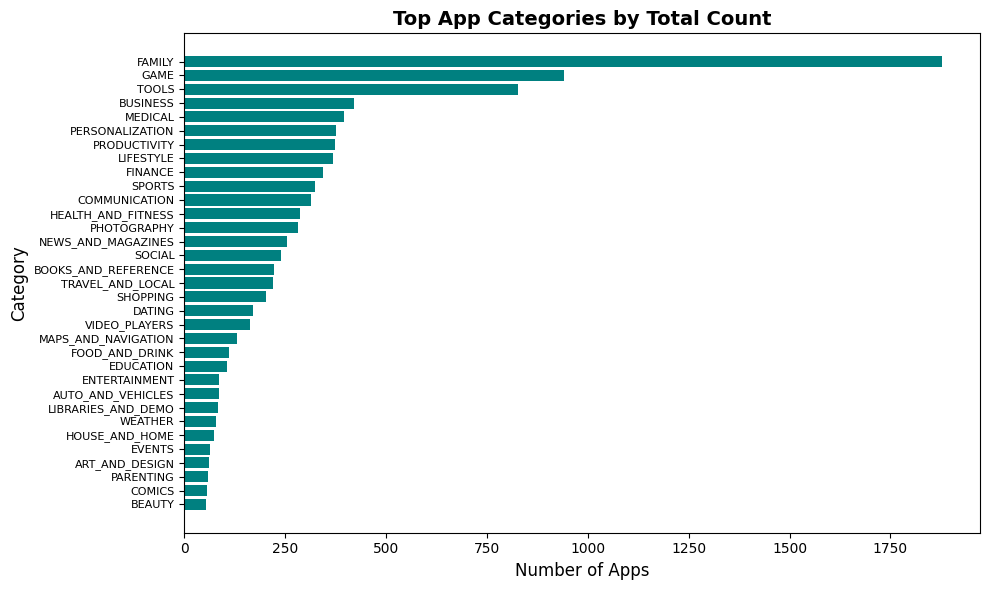

In [118]:
# Chart - 1 visualization code
plt.figure(figsize=(10, 6)) # setting the figure size

# Getting the value counts on categories
category_counts = play_store_df1['Category'].value_counts()

# using matplotlib for generating horizontal bar chart and choosing color of the bars
plt.barh(category_counts.index, category_counts.values, color='teal')

plt.title('Top App Categories by Total Count', fontsize=14, fontweight='bold') # setting the title
plt.xlabel('Number of Apps', fontsize=12) # setting x-label
plt.ylabel('Category', fontsize=12) # setting y-label
plt.yticks(fontsize =8) # cahanging the size of ticks along y axis

# Inverting Y-axis so the highest count is at the top
plt.gca().invert_yaxis()

plt.tight_layout() # for non overlapping names, titles, etc.
plt.show()

##### 1. Why did you pick the specific chart?

Ideal for Category vs Count: Bar Chart is the best visual for comparing
discrete categories against app count

Clear Labelling: Using horizontal layout prevents long Category names overlapping on the x - axis



##### 2. What is/are the insight(s) found from the chart?

Family, Games, and Tools dominate the play store while niche categories like Beauty and Comics have fewer than 100 apps

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

App makers can have an idea which category to target like mass markets or niche markets

#### Chart - 2

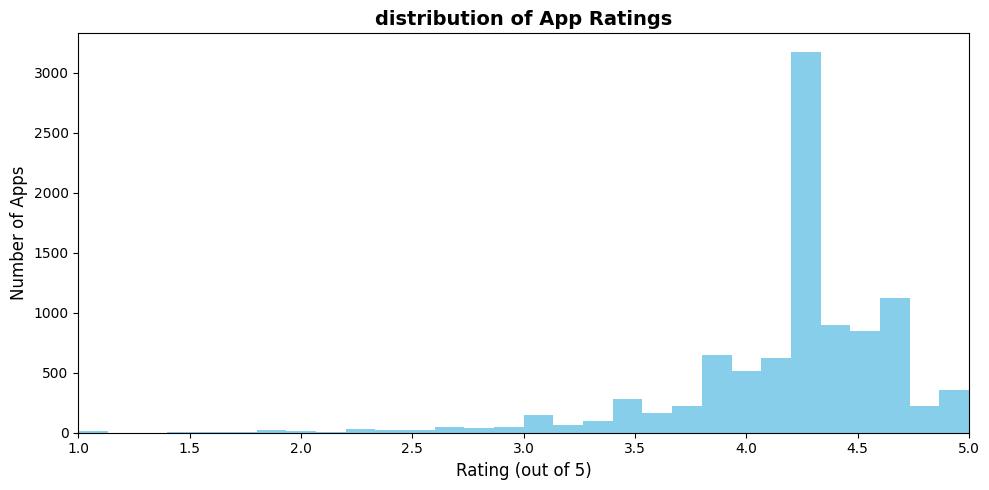

In [100]:
# Chart - 2 visualization code
plt.figure(figsize = (10,5)) # setting the figure size

plt.hist(play_store_df1['Rating'], bins =30, color ='skyblue') # using matplotlib for generating histogram to show distribution of Ratings
plt.title('distribution of App Ratings', fontsize = 14, fontweight = 'bold') # setting the title
plt.xlabel('Rating (out of 5)', fontsize =12) # setting x axis-label
plt.ylabel('Number of Apps', fontsize=12) # setting y axis-label

plt.xlim(1, 5) #setting the limit on x-axis to that the values are clear and consise


plt.tight_layout() # for non overlapping names, titles, etc.
plt.show()

##### 1. Why did you pick the specific chart?

Histogram is ideal for continuous data and easily identifies clusters where much of the data is concentrated

##### 2. What is/are the insight(s) found from the chart?

Most of the apps are highly rated and are concentrated between 4.0 and 4.5 ratings, there are about 3000+ ratings between 4.0 and 4.5. Rare low ratings below 3.0 are observed

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It tells that maintaining 4.0 rating is bare minimum standard across the categories/industries and ratings below 3.0 can drastically lower conversion rates from the users

#### Chart - 3

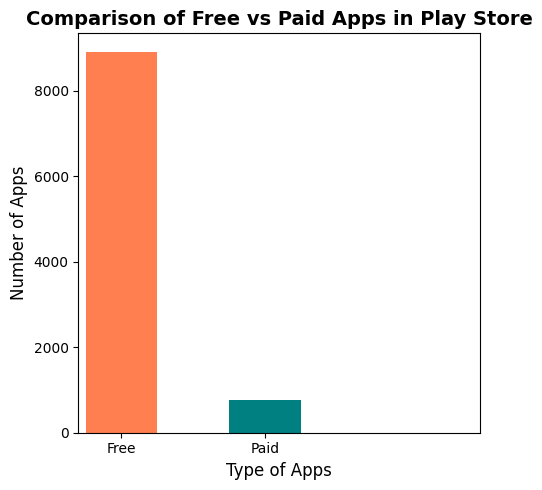

In [101]:
# Chart - 3 visualization code
type_count = play_store_df1['Type'].value_counts() # Getting the value counts on Type column
plt.figure(figsize = (5,5)) # setting the size of the chart

positions = [0, 0.4]

plt.bar(type_count.index, type_count.values, color=['coral', 'teal'], width = 0.5) # Generating bar chart and setting the width

plt.title('Comparison of Free vs Paid Apps in Play Store', fontsize = 14, fontweight= 'bold') # Setting the title for the chart
plt.xlabel('Type of Apps', fontsize = 12) # Setting label for x-axis
plt.ylabel('Number of Apps', fontsize = 12) # setting label  for y- axis
plt.tick_params( axis='both', color = 'black', labelcolor = 'black') # setting tick paramaters to black as I experimented with purple color

plt.xlim(-0.3, 2.5) #setting the limit on x-axis to that the values are clear and consise

plt.tight_layout() # for non overlapping names, titles, etc.

plt.show()

##### 1. Why did you pick the specific chart?

Vertical bar chart with side by side bars comparison works best for distinct categories and highlights imbalances instantly

##### 2. What is/are the insight(s) found from the chart?

Free Apps dominate the market by a huge margin compared to small fraction of paid apps market

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It's suggestable to app makers to start free and after good conversion rates gradually change for in app purchase model. Charging high prices upfront might create severe friction if the users are not satisfied

#### Chart - 4

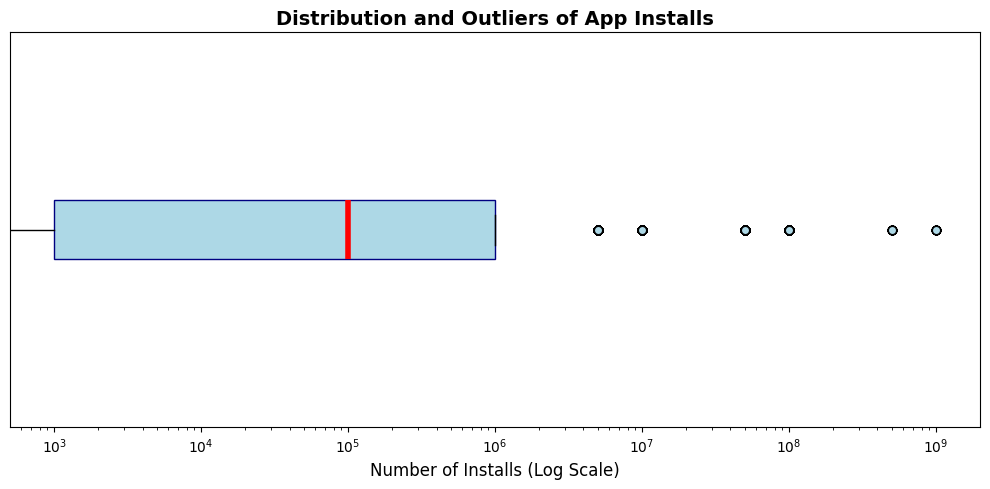

In [102]:
# Chart - 4 visualization code
plt.figure(figsize= (10,5)) # setting the size of the chart


plt.boxplot(play_store_df1['Installs'], vert = False, patch_artist = True,  # generating horizontal box plot by giving vert parameter and setting patch_artist to true so that the box can be filled with color
            boxprops= {'facecolor': 'lightblue', 'color':'Navy'}, # coloring the box for appeal
            medianprops= {'color': 'red', 'linewidth' : 4}, # coloring and setting the width of median line
            flierprops={'markerfacecolor': 'lightblue'}) # filling the outliers

plt.title("Distribution and Outliers of App Installs", fontsize = 14, fontweight = 'bold')  # setting the title for the chart
plt.xlabel("Number of Installs (Log Scale)", fontsize = 12) # setting x-label of the chart

plt.xscale('log') # since the range of numbers was very high from few thousands to billions set the x axis to logarithmic scale for better diepersion
plt.yticks([]) # setting y axis ticks to none as they have no importanc here

plt.tight_layout() # for non overlapping names, titles, etc.
plt.show()

##### 1. Why did you pick the specific chart?

Box plot is best for spotting outliers and spots median of the data immediately.

##### 2. What is/are the insight(s) found from the chart?

Most of the app installs are between 10^3 and 10^6 with few outliers reaching 10^9 installs

In [103]:
play_store_df1['Installs'].median()

100000.0

In [104]:
print(play_store_df1['Installs'].mean())

7780207.840045554


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

App developers need to consider median installs to set the standard or goal instead for mean because mean would go really high because of the extreme outliers present in the data ranging from 10^7 to 10^9 which can be unrealistic target at the start as shown above

#### Chart - 5

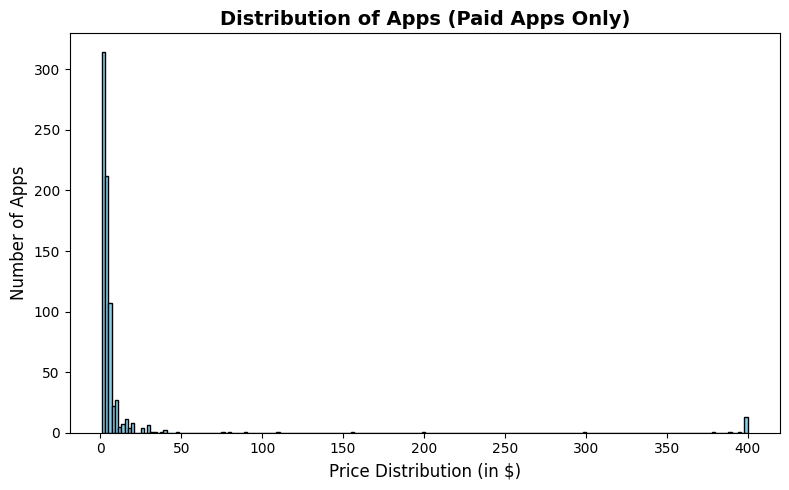

In [105]:
# Chart - 5 visualization code
paid_apps = play_store_df1[play_store_df1['Price']>0]

plt.figure(figsize = (8,5)) # setting the size of the chart


plt.hist(paid_apps['Price'], bins = 200, color ='skyblue', edgecolor = 'black') # generating histogram for the paid apps distribution and settings bins
plt.title('Distribution of Apps (Paid Apps Only)', fontsize = 14, fontweight = 'bold') # setting the title for the chart
plt.xlabel('Price Distribution (in $)', fontsize =12) # setting label  for x- axis
plt.ylabel('Number of Apps', fontsize = 12) # setting label  for y- axis

plt.tight_layout() # for non overlapping names, titles, etc.


plt.show()

##### 1. Why did you pick the specific chart?

We wanted to know how apps are priced and since price is a continuous variable histogram is best suited chart to observe the data

##### 2. What is/are the insight(s) found from the chart?

Vast majority of apps are priced below 20 dollars and there is a tiny cluster targeting luxury pricing for high end apps.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

If App makers were to develop a priced app this chart clearly shows them where they have to target because setting high initial prices let's say above 50 dollars might lead to resistance

#### Chart - 6

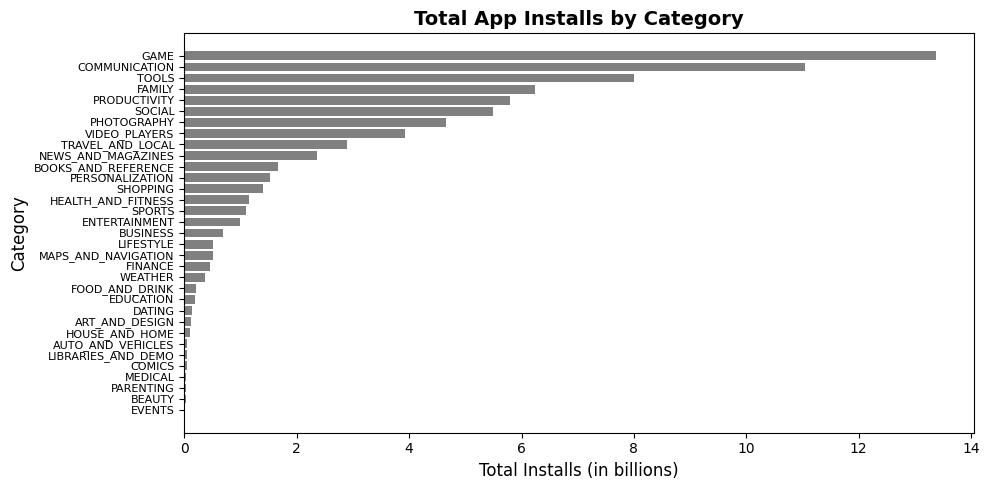

In [106]:
# Chart - 6 visualization code
category_installs = (play_store_df1.groupby('Category')['Installs'].sum()/1e9).sort_values(ascending = True)
plt.figure(figsize= (10,5))

plt.barh(category_installs.index, category_installs.values, color = 'grey')
plt.title('Total App Installs by Category', fontsize = 14, fontweight ='bold')
plt.xlabel('Total Installs (in billions)', fontsize = 12)
plt.ylabel('Category', fontsize = 12)
plt.xticks(fontsize =10)
plt.yticks(fontsize =8)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar Chart best represents multiple categories vs aggregated totals

##### 2. What is/are the insight(s) found from the chart?

Game, communication, and Tools occupy top position in installs inspite being less in number of categories compared to family

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This can guide advertisement and marketing companies to know where to place there ads for maximum conversion or impressions

#### Chart - 7

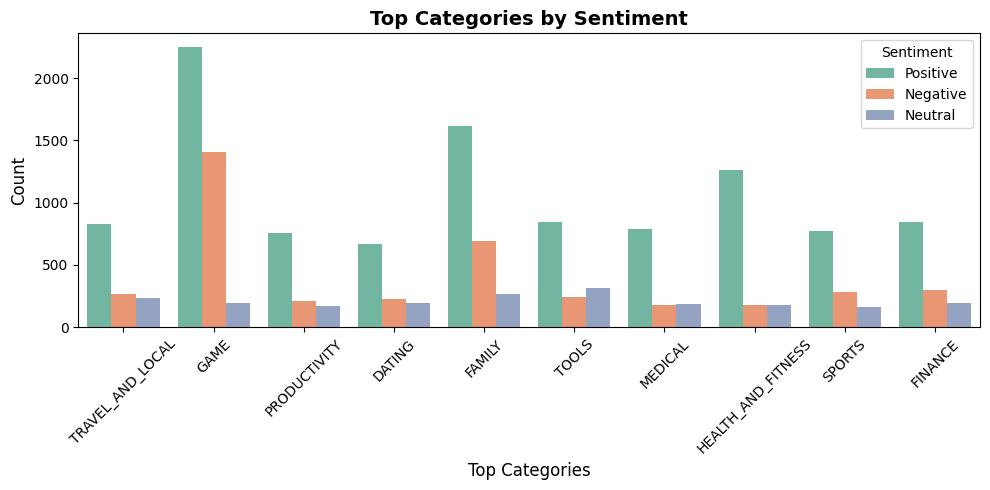

In [107]:
# Chart - 7 visualization code
top_cats = merged_df['Category'].value_counts().head(10).index # We get the column  names
filtered_df = merged_df[merged_df['Category'].isin(top_cats)] # we filter out top ten categories for plotting count plot

plt.figure(figsize =(10,5)) # set the figure size

sns.countplot(filtered_df, x= 'Category', hue ='Sentiment', palette ='Set2') # plotting countplot with Sentiment as hue
plt.title('Top Categories by Sentiment', fontsize =14, fontweight ='bold') # title of the chart
plt.xlabel('Top Categories', fontsize = 12) # x label
plt.ylabel('Count', fontsize = 12) # y label of the chart
plt.xticks(rotation = 45) # we rotate x ticks to 45 degrees so as to avoid overlapping
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Countplot is ideal for grouped categorical comparison, we can clearly see the overall volume of reviews along with the sentiment breakdown

##### 2. What is/are the insight(s) found from the chart?

Game and Family categories register highest number positive reviews, but it has to be noted that they have drawn substantial amount of negative sentiment too

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

high amounts about negative sentiment in games tell us that users are at some point unimpressed by the performance or upgrades or ads being placed in middle

#### Chart - 8

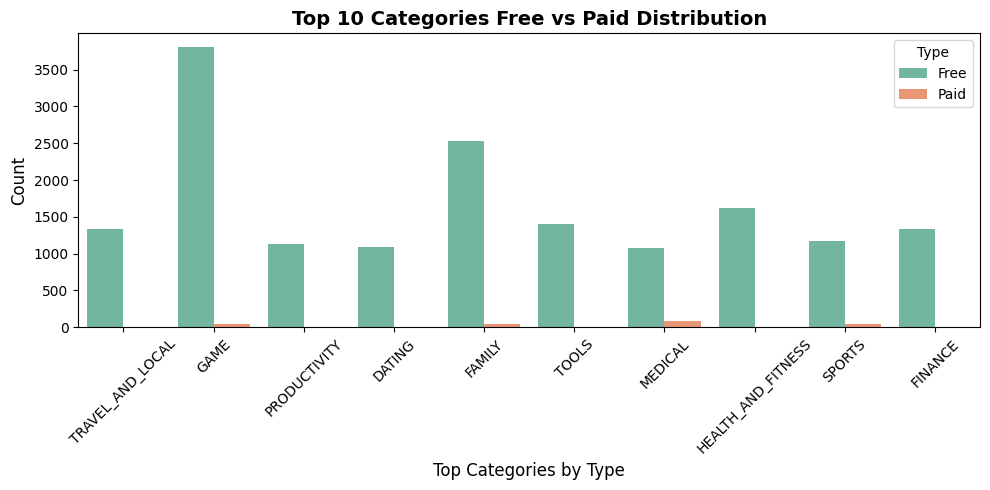

In [108]:
# Chart - 8 visualization code

plt.figure(figsize = (10,5))


top_cats2 = merged_df['Category'].value_counts().head(10).index

filtered_df1 = merged_df[merged_df['Category'].isin(top_cats2)]

sns.countplot(filtered_df1, x = 'Category', hue = 'Type', palette = 'Set2')

plt.title('Top 10 Categories Free vs Paid Distribution', fontsize = 14, fontweight = 'bold')

plt.xlabel('Top Categories by Type', fontsize =12)
plt.ylabel('Count', fontsize = 12)
plt.xticks(rotation = 45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart effectively compares continuous counts across multiple categories broken down by app type (Free vs. Paid).

##### 2. What is/are the insight(s) found from the chart?

Free apps heavily dominate all top 10 categories, led by massive volume in Game (approx 3,800 free) and Family (approx 2,500 free).
Although we observe that paid apps are slightly encouraged in medical category. It can be observed from the above two charts that top apps are free to the users implying they are generating revenue from in app purchases or ads, that is where we can see spike in the negative reviews too which is people complaining about ads or in app purchases to perform better

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

ad-supported model is suggested across all major app categories to gain market traction.

#### Chart - 9

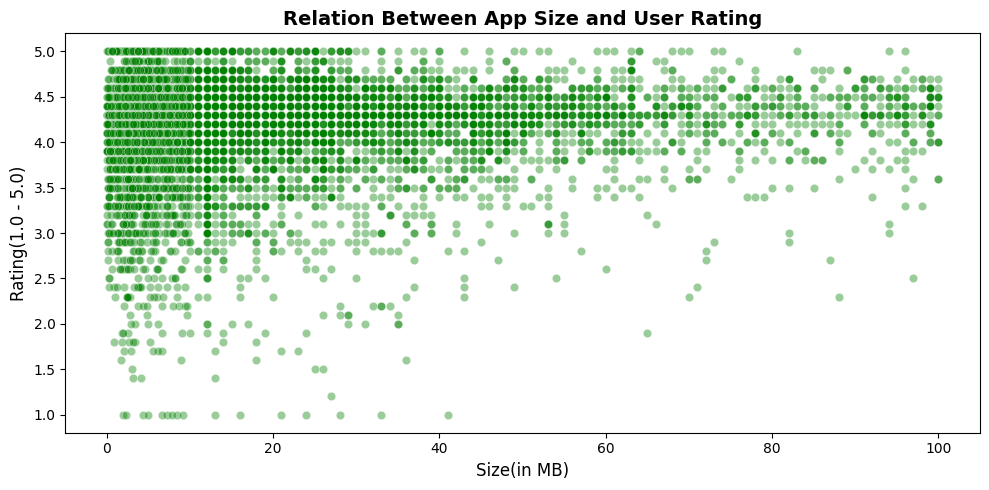

In [109]:
# Chart - 9 visualization code
plt.figure(figsize=(10,5))

sns.scatterplot(play_store_df1, x='Size', y='Rating', alpha = 0.4, color ='green')
plt.title('Relation Between App Size and User Rating', fontsize =14, fontweight='bold')
plt.xlabel('Size(in MB)', fontsize = 12)
plt.ylabel('Rating(1.0 - 5.0)', fontsize = 12)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for continuous correlation to observe relationship and cluster points between two numerical variables like size and rating

##### 2. What is/are the insight(s) found from the chart?

Ratings are distributed across all sizes, showing that an app's size does not directly dictate its user rating indicating weak correlation but we can observe that there are large cluster of apps concentrated from 0 to 40 MB sizes and maintaining steady rating values above 3.5

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

App developers can focus on quality of the apps without worrying about the size as we can observe size does not impact the ratings as long as the app delivers

#### Chart - 10

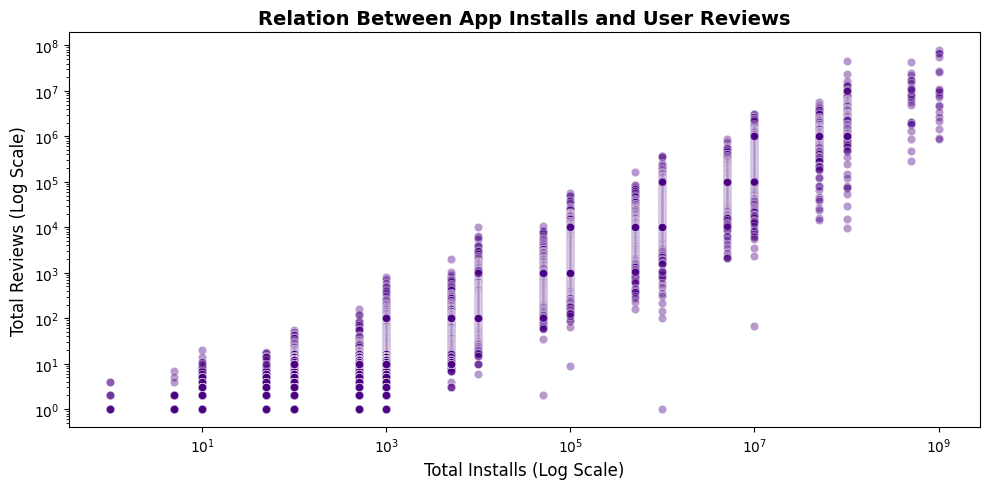

In [110]:
# Chart - 10 visualization code

plt.figure(figsize=(10,5))

sns.scatterplot(play_store_df1, x= 'Installs', y='Reviews', alpha = 0.4, color ='indigo')

plt.title('Relation Between App Installs and User Reviews', fontsize = 14, fontweight = 'bold')
plt.xlabel('Total Installs (Log Scale)', fontsize=12)
plt.ylabel('Total Reviews (Log Scale)', fontsize=12)

plt.xscale('log')
plt.yscale('log')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for plotting or revealing the realtionship between two variables

##### 2. What is/are the insight(s) found from the chart?

Clear positive correlation observed between app installs and reviews. As the number of installs goes up so does the number of reviews

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

proves that social acceptance is built or driven through number of installs and subsequent positive reviews.

An app with high installs and low reviews indicate either poor retention or enagement with the users

#### Chart - 11

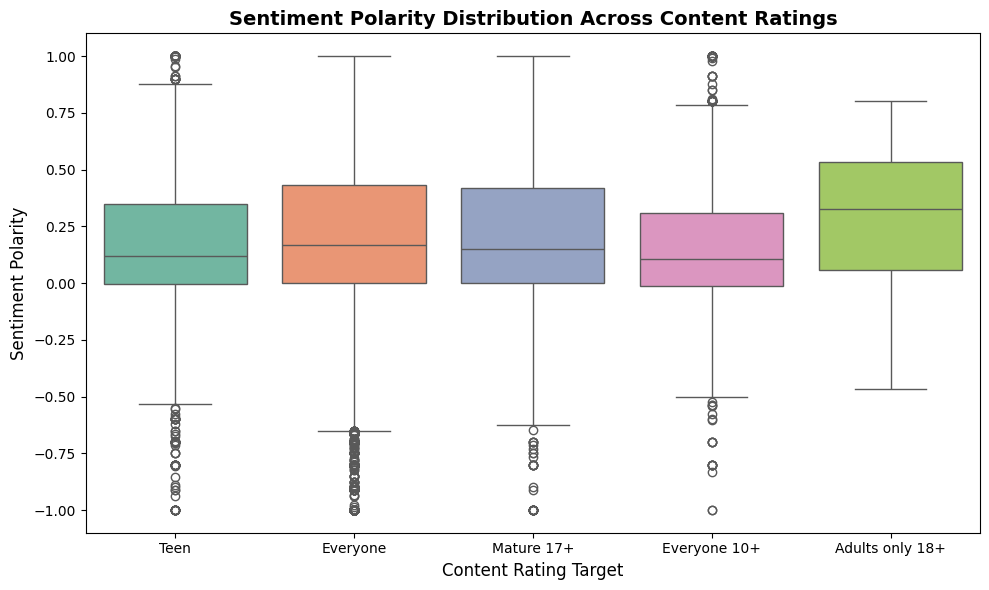

In [111]:
# Chart - 11 visualization code

plt.figure(figsize=(10, 6))
sns.boxplot(
    merged_df,
    x='Content Rating',
    y='Sentiment_Polarity',
    hue='Content Rating',  # Assign hue to match x
    legend=False,          # remove the redundant legend
    palette='Set2'
)
plt.title('Sentiment Polarity Distribution Across Content Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Content Rating Target', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Box plot is preferred to observe median, variance, and spread at a glance for a metric like Sentiment Polarity against content rating taken as hue, It also highlights where the outliers are concentrated

##### 2. What is/are the insight(s) found from the chart?

Adults only 18+ content rating has the highest median among the all, while all of have maintained positive polarity median above zero.

There are extreme outliers incling both sides in all of the contents except for the adult 18+

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Although there is an overall positive median, content rating like teens show extreme negative polarity signaling if their expectation are not met, they turn harsh real fast

#### Chart - 12

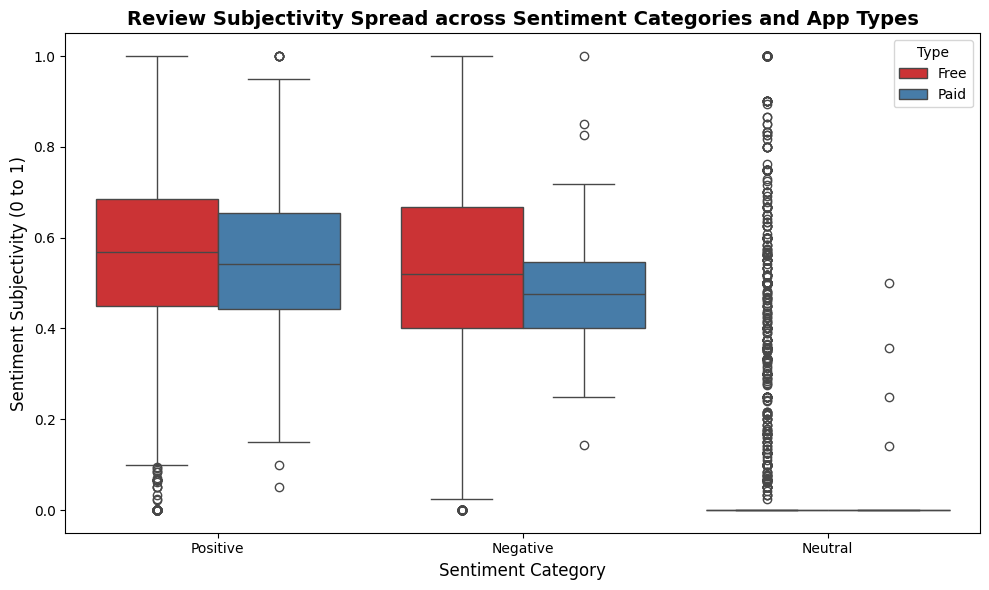

In [112]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))

sns.boxplot(merged_df, x='Sentiment', y='Sentiment_Subjectivity', hue='Type', palette='Set1')

plt.title('Review Subjectivity Spread across Sentiment Categories and App Types', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Sentiment Subjectivity (0 to 1)', fontsize=12)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped box plot best compares the spread, median, and variance of a continuous metric (Subjectivity) across sentiment groups broken down by app type (Free vs. Paid).

##### 2. What is/are the insight(s) found from the chart?

Both Positive and Negative sentiment reviews show higher median subjectivity (~0.5 to 0.6), indicating strong opinions or feedback from the users

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights will help app makers to look onto/filter out highly subjective opinions where detailed reviews are written for app imperovement.

#### Chart - 13

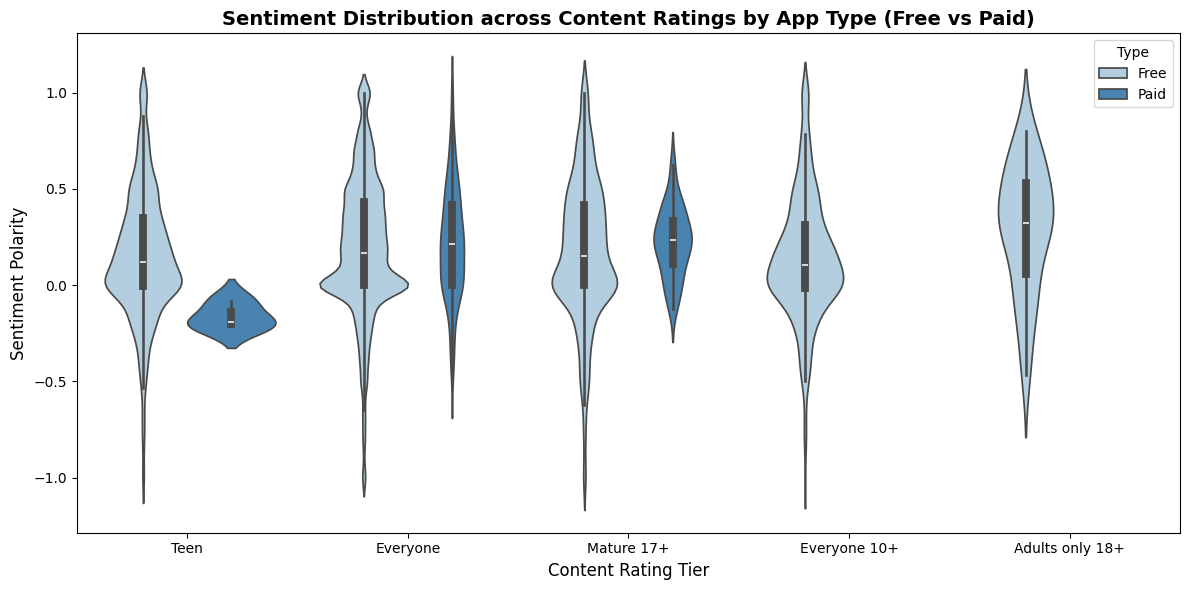

In [119]:
# Chart - 13 visualization code
plt.figure(figsize=(12, 6))

sns.violinplot(merged_df, x='Content Rating', y='Sentiment_Polarity', hue='Type',palette='Blues')

plt.title('Sentiment Distribution across Content Ratings by App Type (Free vs Paid)', fontsize=14, fontweight='bold')
plt.xlabel('Content Rating Tier', fontsize=12)
plt.ylabel('Sentiment Polarity', fontsize=12)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Violin plot is more like blox plot with density curves to show overall distribution shape along with nedian sentiment

##### 2. What is/are the insight(s) found from the chart?

Free apps across all age tiers maintain a positive median sentiment (~0.15–0.30), though they carry long tails of negative reviews.

The Everyone 10+ and Adults only 18+ tiers lack paid app sentiment data, highlighting a market heavily dominated by free models.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Looking at the data it is suggested to stick to advertising revenue or in app purchases for the Everyone 10+ and Adults only 18+ content ratings as there are many apps fighting for space there

#### Chart - 14 - Correlation Heatmap

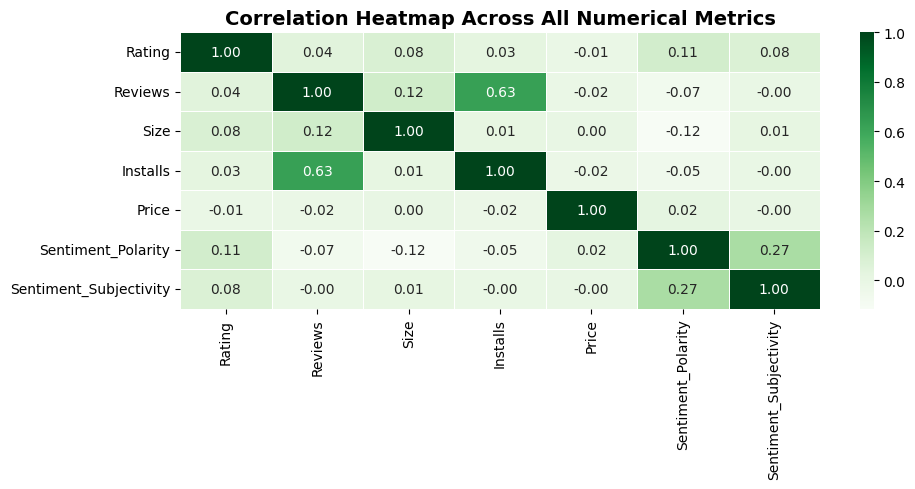

In [114]:
# Correlation Heatmap visualization code
corr_matrix = merged_df[['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Sentiment_Polarity', 'Sentiment_Subjectivity']].corr()

plt.figure(figsize = (10,5))

sns.heatmap(corr_matrix, annot = True, cmap = 'Greens',fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap Across All Numerical Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap efficiently summarizes the relationship strength between all continuous numerical variables in a single view

We can easily identify strength measure by color intensity

##### 2. What is/are the insight(s) found from the chart?

Except for ratings vs installs and polatrity vs subjectivity all other numerical variables show near zero correlation indicating they almost are independent of each other.

#### Chart - 15 - Pair Plot

<Figure size 800x500 with 0 Axes>

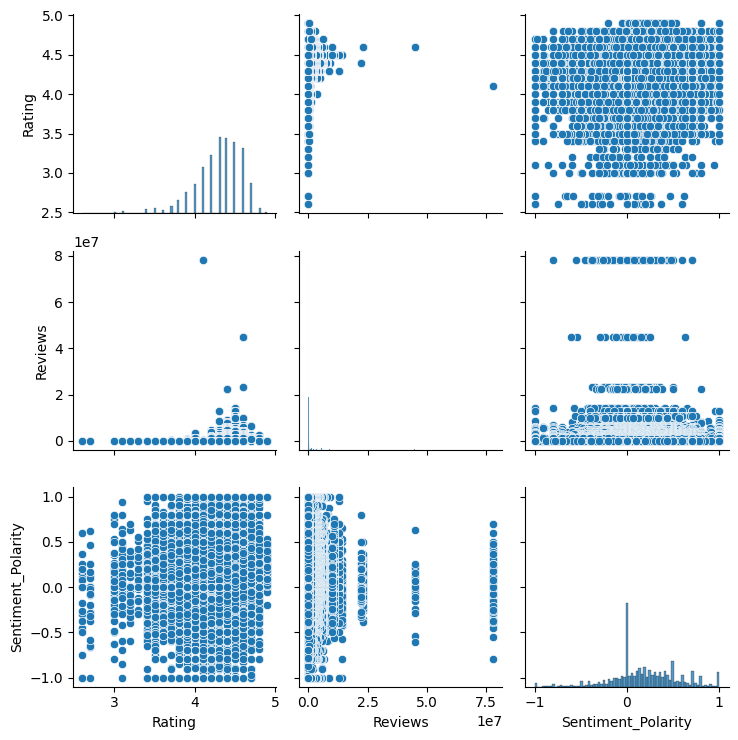

In [115]:
# Pair Plot visualization code
plt.figure(figsize=(8,5))
sns.pairplot(merged_df[['Rating', 'Reviews', 'Sentiment_Polarity']])
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot visualizes pairwise scatter plots across numerical variables while displaying distribution enabling simultaneous obervation

##### 2. What is/are the insight(s) found from the chart?

Rating is left-skewed with most apps concentrated between 4.0 and 4.5, whereas Reviews is heavily right-skewed with extreme outliers

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?


I would suggest the client to launch free applications with in-app purchases or subscription tiers based model like silver gold diamond in chess.com rather than charging them upfront which might result in less harsh critiques and maximize downloads.

Focus on unsaturated content type markets like everyone 10+ using ad supported models so as to maximize the revenue.

Continuously monitor/filter out negative polarity to identify the problem areas and fix them as soon as possible else users spend no time looking for alternatives or bringing the overall rating down with negative sentiment

# **Conclusion**

It's a highly competitive market with free applications dominating the paid ones with huge margin so freemium models will succeed and lead to higher revenue generation given the positive ratings and sentiments are maintained.

User ratings strongly correlate with sentiment polatrity, addressing the feedback early will help with user retention.

Niche categories like beauty and comics offer prime opportunities for app developers to capture market share.




### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***